In [1]:
#Simualting theft and building models

In [2]:
import pandas as pd

df_sim = pd.read_csv("../data/processed/clean_resampled.csv")

In [3]:
df_sim.head()


,x_Timestamp,meter,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),hour,day,month,day_of_week
0,2021-01-02 00:00:00,BR02,0.00850,253.9020,0.7160,50.0535,0,2,1,5
1,2021-01-02 01:00:00,BR02,0.00105,255.0410,0.1425,50.0170,1,2,1,5
2,2021-01-02 02:00:00,BR02,0.00100,255.4345,0.1335,49.9955,2,2,1,5
3,2021-01-02 03:00:00,BR02,0.00100,255.7510,0.1320,50.0160,3,2,1,5
4,2021-01-02 04:00:00,BR02,0.00100,255.8580,0.1300,50.0285,4,2,1,5


In [4]:
df_sim.shape

(165436, 10)

In [5]:
df_sim['x_Timestamp'] = pd.to_datetime(df_sim['x_Timestamp'])

In [6]:
df_sim['theft'] = 0

In [7]:
df_sim.head()

,x_Timestamp,meter,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),hour,day,month,day_of_week,theft
0,2021-01-02 00:00:00,BR02,0.00850,253.9020,0.7160,50.0535,0,2,1,5,0
1,2021-01-02 01:00:00,BR02,0.00105,255.0410,0.1425,50.0170,1,2,1,5,0
2,2021-01-02 02:00:00,BR02,0.00100,255.4345,0.1335,49.9955,2,2,1,5,0
3,2021-01-02 03:00:00,BR02,0.00100,255.7510,0.1320,50.0160,3,2,1,5,0
4,2021-01-02 04:00:00,BR02,0.00100,255.8580,0.1300,50.0285,4,2,1,5,0


In [8]:
#Selecting rows for theft (10%)
import numpy as np

# Total rows
n = len(df_sim)

# 10% of data
n_theft = int(0.10 * n)

# Randomly select indices
np.random.seed(42)  # for reproducibility
theft_indices = np.random.choice(df_sim.index, size=n_theft, replace=False)

In [9]:
len(theft_indices)

16543

In [10]:
meters = df_sim['meter'].unique()

np.random.seed(42)
selected_meters = np.random.choice(meters, size=int(0.2 * len(meters)), replace=False)

selected_meters

array(['BR50', 'BR29', 'BR22', 'BR37', 'BR15'], dtype=object)

In [22]:
# import pandas as pd
# import numpy as np

# # Convert timestamp just to be safe
# df_sim['x_Timestamp'] = pd.to_datetime(df_sim['x_Timestamp'])

# # Store theft windows
# theft_windows = []

# np.random.seed(42)

# for meter in selected_meters:
    
#     meter_df = df_sim[df_sim['meter'] == meter]
    
#     # Get unique timestamps
#     timestamps = meter_df['x_Timestamp'].sort_values().unique()
    
#     # Pick random start index
#     start_idx = np.random.randint(0, len(timestamps) - 200)
    
#     # Random duration (3 to 7 days → 72 to 168 hours)
#     duration = np.random.randint(72, 168)
    
#     start_time = timestamps[start_idx]
#     end_time = timestamps[start_idx + duration]
    
#     theft_windows.append((meter, start_time, end_time))

# # View windows
# theft_windows

#Claude update

import pandas as pd
import numpy as np

df_sim = pd.read_csv("../data/processed/clean_resampled.csv")
df_sim['x_Timestamp'] = pd.to_datetime(df_sim['x_Timestamp'])
df_sim['theft'] = 0

np.random.seed(42)

# ── helpers ──────────────────────────────────────────────────────────────────

THEFT_TYPES = ['load', 'flat', 'intermittent', 'drop', 'bypass']

def apply_theft_pattern(df, mask, theft_type):
    """Apply one theft pattern. Returns modified df."""
    df = df.copy()

    if theft_type == 'load':
        factor = np.random.uniform(0.3, 0.5)
        df.loc[mask, 't_kWh'] *= factor

    elif theft_type == 'flat':
        mean_val = df.loc[mask, 't_kWh'].mean()
        if mean_val > 0:                      # guard: don't flatten already-zero windows
            df.loc[mask, 't_kWh'] = mean_val

    elif theft_type == 'intermittent':
        idx = df.loc[mask].index
        # FIX Issue 3: only label alternating hours as theft
        # We'll handle labelling separately below
        df.loc[idx[::2], 't_kWh'] *= 0.4

    elif theft_type == 'drop':
        df.loc[mask, 't_kWh'] *= 0.2

    elif theft_type == 'bypass':
        df.loc[mask, 't_kWh'] *= 0.05

    return df


def no_overlap(existing_windows, meter, start, end):
    """Return True if (meter, start, end) does not overlap any existing window."""
    for (m, s, e, _) in existing_windows:
        if m == meter:
            # overlap exists if not (end < s or start > e)
            if not (end < s or start > e):
                return False
    return True


# ── select meters ─────────────────────────────────────────────────────────────

meters = df_sim['meter'].unique()

# 10 meters flagged for theft (~34% of 29 meters — realistic)
np.random.seed(42)
theft_meters = np.random.choice(meters, size=10, replace=False)
print("Theft meters:", theft_meters)

# ── generate non-overlapping windows ─────────────────────────────────────────

all_windows = []   # list of (meter, start, end, theft_type)

for meter in theft_meters:
    meter_df = df_sim[df_sim['meter'] == meter]
    timestamps = meter_df['x_Timestamp'].sort_values().unique()

    n_windows = np.random.randint(6, 11)   # 6–10 windows per meter
    attempts = 0

    while len([w for w in all_windows if w[0] == meter]) < n_windows:
        attempts += 1
        if attempts > 500:   # safety — avoid infinite loop for short meters
            break

        start_idx = np.random.randint(0, len(timestamps) - 400)
        duration  = np.random.randint(168, 360)   # 7–15 days in hours
        end_idx   = min(start_idx + duration, len(timestamps) - 1)

        start_time = timestamps[start_idx]
        end_time   = timestamps[end_idx]

        if no_overlap(all_windows, meter, start_time, end_time):
            theft_type = np.random.choice(THEFT_TYPES)
            all_windows.append((meter, start_time, end_time, theft_type))

print(f"\nTotal non-overlapping theft windows: {len(all_windows)}")
for w in all_windows:
    print(f"  {w[0]} | {w[1].date()} → {w[2].date()} | {w[3]}")

Theft meters: ['BR50' 'BR29' 'BR22' 'BR37' 'BR15' 'BR16' 'BR36' 'BR02' 'BR49' 'BR24']

Total non-overlapping theft windows: 67
  BR50 | 2021-02-18 → 2021-03-05 | drop
  BR50 | 2021-05-01 → 2021-05-09 | intermittent
  BR50 | 2021-03-26 → 2021-04-04 | drop
  BR50 | 2021-03-10 → 2021-03-23 | bypass
  BR50 | 2021-06-23 → 2021-07-05 | bypass
  BR50 | 2021-04-18 → 2021-04-29 | drop
  BR50 | 2021-05-18 → 2021-06-04 | flat
  BR50 | 2021-01-07 → 2021-01-24 | drop
  BR29 | 2021-02-13 → 2021-03-01 | bypass
  BR29 | 2021-01-15 → 2021-01-27 | bypass
  BR29 | 2021-07-28 → 2021-08-10 | load
  BR29 | 2021-08-13 → 2021-08-21 | bypass
  BR29 | 2021-01-03 → 2021-01-14 | load
  BR29 | 2021-08-21 → 2021-09-02 | drop
  BR29 | 2021-04-26 → 2021-05-05 | intermittent
  BR29 | 2021-07-12 → 2021-07-21 | intermittent
  BR29 | 2021-09-08 → 2021-09-16 | drop
  BR22 | 2021-09-08 → 2021-09-16 | flat
  BR22 | 2021-05-11 → 2021-05-20 | bypass
  BR22 | 2021-09-20 → 2021-10-04 | intermittent
  BR22 | 2021-03-07 → 2021-03

In [23]:
# ── apply theft patterns + fix label noise (Issue 3) ─────────────────────────

for meter, start, end, theft_type in all_windows:

    mask = (
        (df_sim['meter'] == meter) &
        (df_sim['x_Timestamp'] >= start) &
        (df_sim['x_Timestamp'] <= end)
    )

    df_sim = apply_theft_pattern(df_sim, mask, theft_type)

    # FIX Issue 3: for intermittent, only label the MODIFIED rows as theft
    # For all other patterns every row in the window is modified → label all
    if theft_type == 'intermittent':
        idx = df_sim.loc[mask].index
        df_sim.loc[idx[::2], 'theft'] = 1      # only alternating hours labelled
    else:
        df_sim.loc[mask, 'theft'] = 1

# ── check result ─────────────────────────────────────────────────────────────

print("Final theft distribution:")
print(df_sim['theft'].value_counts())
print(f"\nTheft %: {df_sim['theft'].mean()*100:.1f}%")

# Verify no compounding — check a theft meter's min value
for meter in theft_meters[:3]:
    m_df = df_sim[df_sim['meter'] == meter]
    print(f"{meter} — min kWh: {m_df['t_kWh'].min():.5f}")

Final theft distribution:
theft
0    149103
1     16333
Name: count, dtype: int64

Theft %: 9.9%
BR50 — min kWh: 0.00000
BR29 — min kWh: 0.00000
BR22 — min kWh: 0.00000


In [ ]:
# #Apply theft patterns

# for meter, start, end in theft_windows:
    
#     mask = (
#         (df_sim['meter'] == meter) &
#         (df_sim['x_Timestamp'] >= start) &
#         (df_sim['x_Timestamp'] <= end)
#     )
    
#     # Load Suppression
#     if meter == 'BR50':
#         factor = np.random.uniform(0.3, 0.5)
#         df_sim.loc[mask, 't_kWh'] *= factor
    
#     # Flat Consumption
#     elif meter == 'BR29':
#         mean_val = df_sim.loc[mask, 't_kWh'].mean()
#         df_sim.loc[mask, 't_kWh'] = mean_val
    
#     # Intermittent Theft
#     elif meter == 'BR22':
#         idx = df_sim.loc[mask].index
#         df_sim.loc[idx[::2], 't_kWh'] *= 0.4  # every alternate hour
    
#     # Sudden Drop
#     elif meter == 'BR37':
#         df_sim.loc[mask, 't_kWh'] *= 0.2
    
#     # Meter Bypass
#     elif meter == 'BR15':
#         df_sim.loc[mask, 't_kWh'] = df_sim.loc[mask, 't_kWh'] * 0.05

#     # Mark theft
#     df_sim.loc[mask, 'theft'] = 1

In [24]:
df_sim.to_csv("../data/processed/simulated_theft_data.csv", index=False)
print("Saved ✅")

Saved ✅


In [ ]:
#  created:

# Pattern	        Behavior
# Load suppression	reduced usage
# Flat	            constant usage
# Intermittent	    irregular pattern
# Sudden drop	    sharp fall
# Bypass	        near-zero

In [25]:
df_sim['theft'].value_counts()

theft
0    149103
1     16333
Name: count, dtype: int64

In [20]:
df_sim = df_sim.copy()
df_sim['theft'] = 0

In [22]:
df_sim.head()

,x_Timestamp,meter,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),hour,day,month,day_of_week,theft
0,2021-01-02 00:00:00,BR02,0.00850,253.9020,0.7160,50.0535,0,2,1,5,0
1,2021-01-02 01:00:00,BR02,0.00105,255.0410,0.1425,50.0170,1,2,1,5,0
2,2021-01-02 02:00:00,BR02,0.00100,255.4345,0.1335,49.9955,2,2,1,5,0
3,2021-01-02 03:00:00,BR02,0.00100,255.7510,0.1320,50.0160,3,2,1,5,0
4,2021-01-02 04:00:00,BR02,0.00100,255.8580,0.1300,50.0285,4,2,1,5,0


In [ ]:
# theft_windows = []

# np.random.seed(42)

# for meter in selected_meters:
    
#     meter_df = df_sim[df_sim['meter'] == meter]
#     timestamps = meter_df['x_Timestamp'].sort_values().unique()
    
#     # 5 to 7 windows per meter
#     n_windows = np.random.randint(5, 8)
    
#     for _ in range(n_windows):
        
#         start_idx = np.random.randint(0, len(timestamps) - 300)
        
#         # 7 to 15 days → 168 to 360 hours
#         duration = np.random.randint(168, 360)
        
#         start_time = timestamps[start_idx]
#         end_time = timestamps[start_idx + duration]
        
#         theft_windows.append((meter, start_time, end_time))

# len(theft_windows)

32

In [20]:
# len(theft_windows)

In [ ]:
# for meter, start, end in theft_windows:
    
#     mask = (
#         (df_sim['meter'] == meter) &
#         (df_sim['x_Timestamp'] >= start) &
#         (df_sim['x_Timestamp'] <= end)
#     )
    
#     # Randomly assign a theft type for each window
#     theft_type = np.random.choice(['load', 'flat', 'intermittent', 'drop', 'bypass'])
    
#     # Load Suppression
#     if theft_type == 'load':
#         factor = np.random.uniform(0.3, 0.5)
#         df_sim.loc[mask, 't_kWh'] *= factor
    
#     # Flat Consumption
#     elif theft_type == 'flat':
#         mean_val = df_sim.loc[mask, 't_kWh'].mean()
#         df_sim.loc[mask, 't_kWh'] = mean_val
    
#     # Intermittent Theft
#     elif theft_type == 'intermittent':
#         idx = df_sim.loc[mask].index
#         df_sim.loc[idx[::2], 't_kWh'] *= 0.4
    
#     # Sudden Drop
#     elif theft_type == 'drop':
#         df_sim.loc[mask, 't_kWh'] *= 0.2
    
#     # Meter Bypass
#     elif theft_type == 'bypass':
#         df_sim.loc[mask, 't_kWh'] *= 0.05
    
#     # Mark theft
#     df_sim.loc[mask, 'theft'] = 1

In [ ]:
# df_sim['theft'].value_counts()

theft
0    158036
1      7400
Name: count, dtype: int64

In [ ]:
# #adding more windows for theft
# extra_windows = []

# for meter in selected_meters:
    
#     meter_df = df_sim[df_sim['meter'] == meter]
#     timestamps = meter_df['x_Timestamp'].sort_values().unique()
    
#     # Add 2–3 more windows
#     n_extra = np.random.randint(2, 4)
    
#     for _ in range(n_extra):
        
#         start_idx = np.random.randint(0, len(timestamps) - 300)
#         duration = np.random.randint(168, 360)
        
#         start_time = timestamps[start_idx]
#         end_time = timestamps[start_idx + duration]
        
#         extra_windows.append((meter, start_time, end_time))

In [ ]:
# for meter, start, end in extra_windows:
    
#     mask = (
#         (df_sim['meter'] == meter) &
#         (df_sim['x_Timestamp'] >= start) &
#         (df_sim['x_Timestamp'] <= end)
#     )
    
#     theft_type = np.random.choice(['load', 'flat', 'intermittent', 'drop', 'bypass'])
    
#     if theft_type == 'load':
#         df_sim.loc[mask, 't_kWh'] *= np.random.uniform(0.3, 0.5)
    
#     elif theft_type == 'flat':
#         mean_val = df_sim.loc[mask, 't_kWh'].mean()
#         df_sim.loc[mask, 't_kWh'] = mean_val
    
#     elif theft_type == 'intermittent':
#         idx = df_sim.loc[mask].index
#         df_sim.loc[idx[::2], 't_kWh'] *= 0.4
    
#     elif theft_type == 'drop':
#         df_sim.loc[mask, 't_kWh'] *= 0.2
    
#     elif theft_type == 'bypass':
#         df_sim.loc[mask, 't_kWh'] *= 0.05
    
#     df_sim.loc[mask, 'theft'] = 1

In [ ]:
# df_sim['theft'].value_counts()

theft
0    154732
1     10704
Name: count, dtype: int64

In [ ]:
# remaining_meters = list(set(df_sim['meter'].unique()) - set(selected_meters))

# np.random.seed(42)
# new_meters = np.random.choice(remaining_meters, size=3, replace=False)

# new_meters

array(['BR18', 'BR12', 'BR05'], dtype='<U4')

In [ ]:
# new_windows = []

# for meter in new_meters:
    
#     meter_df = df_sim[df_sim['meter'] == meter]
#     timestamps = meter_df['x_Timestamp'].sort_values().unique()
    
#     # 4–10 windows per new meter
#     n_windows = np.random.randint(4, 11)
    
#     for _ in range(n_windows):
        
#         start_idx = np.random.randint(0, len(timestamps) - 300)
#         duration = np.random.randint(168, 360)  # 7–15 days
        
#         start_time = timestamps[start_idx]
#         end_time = timestamps[start_idx + duration]
        
#         new_windows.append((meter, start_time, end_time))

# len(new_windows)

25

In [ ]:
# #Apply theft on NEW meters ..new windows
# for meter, start, end in new_windows:
    
#     mask = (
#         (df_sim['meter'] == meter) &
#         (df_sim['x_Timestamp'] >= start) &
#         (df_sim['x_Timestamp'] <= end)
#     )
    
#     theft_type = np.random.choice(['load', 'flat', 'intermittent', 'drop', 'bypass'])
    
#     if theft_type == 'load':
#         df_sim.loc[mask, 't_kWh'] *= np.random.uniform(0.3, 0.5)
    
#     elif theft_type == 'flat':
#         mean_val = df_sim.loc[mask, 't_kWh'].mean()
#         df_sim.loc[mask, 't_kWh'] = mean_val
    
#     elif theft_type == 'intermittent':
#         idx = df_sim.loc[mask].index
#         df_sim.loc[idx[::2], 't_kWh'] *= 0.4
    
#     elif theft_type == 'drop':
#         df_sim.loc[mask, 't_kWh'] *= 0.2
    
#     elif theft_type == 'bypass':
#         df_sim.loc[mask, 't_kWh'] *= 0.05
    
#     df_sim.loc[mask, 'theft'] = 1

In [17]:
df_sim['theft'].value_counts()

theft
0    156751
1      8685
Name: count, dtype: int64

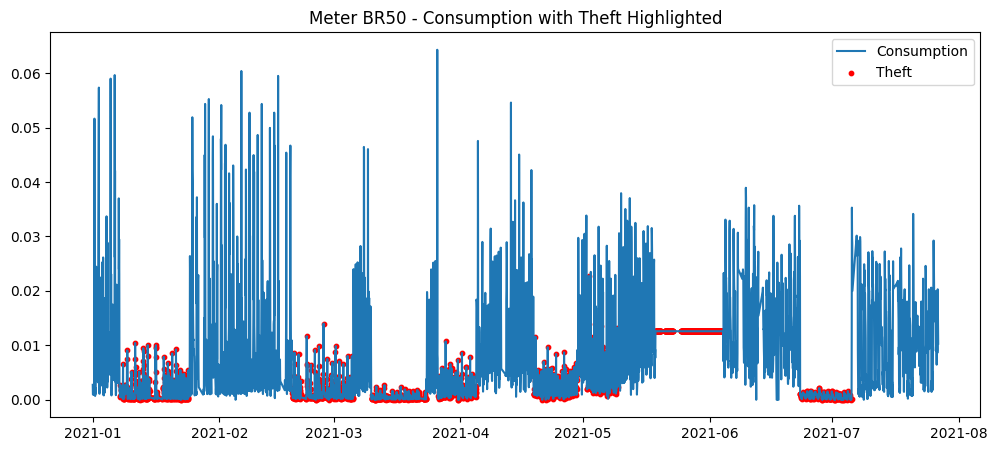

In [26]:
import matplotlib.pyplot as plt

# pick a meter that has theft
meter = selected_meters[0]   # e.g. BR50

temp = df_sim[df_sim['meter'] == meter]

plt.figure(figsize=(12,5))

plt.plot(temp['x_Timestamp'], temp['t_kWh'], label='Consumption')

# highlight theft points
theft_points = temp[temp['theft'] == 1]

plt.scatter(theft_points['x_Timestamp'], theft_points['t_kWh'], 
            color='red', s=10, label='Theft')

plt.title(f"Meter {meter} - Consumption with Theft Highlighted")
plt.legend()
plt.show()

In [ ]:
# (objective analysis)
# ✅ 1. Clear separation between normal and theft
# Blue → normal consumption
# Red → theft

# 👉 Red points are not random → good ✔

# ✅ 2. Continuous theft regions (VERY IMPORTANT)
# You can see clusters of red points
# Not scattered randomly

# 👉 This confirms:

# ✔ Time-window based simulation worked correctly

# ✅ 3. Different theft behaviors visible
# 🔹 Near-zero segments
# Red points close to 0
# 👉 Meter bypass / drop
# 🔹 Flat horizontal segments
# Straight red lines
# 👉 Flat consumption pattern
# 🔹 Reduced noisy segments
# Same pattern but lower amplitude
# 👉 Load suppression
# ⚠️ 4. One minor observation (not a problem)

# Some areas look like:

# Red points overlapping with blue noise

# 👉 That’s because:

# You kept original variability (good)
# Only scaled values

# 👉 This is actually more realistic, not an issue

# 🎯 Verdict
# Criteria	Status
# Temporal continuity	✅
# Pattern realism	✅
# Variety of behaviors	✅
# Non-random distribution	✅


# “The simulated theft patterns show realistic temporal continuity,
#  including sustained drops, flat consumption, and intermittent reductions, closely mimicking real-world tampering behavior.”

In [ ]:
# #final simulated dataset
# df_sim.to_csv("../data/processed/simulated_theft_data.csv", index=False)